# 7. Выход за рамки линейности.

Упражнения из **7 главы** книги [Введение в статистическое обучение](http://www-bcf.usc.edu/~gareth/ISL/) Гарета Джеймса, Даниела Уиттена, Тревора Хасти, Роберта Тибширани, Джонатана Тейлора.

## Практические задания.

### Задание 6.

В этом упражнении мы продолжим анализировать набор данных Wage, с которым работали на протяжении всей главы.

(a) Постройте полиномиальную регрессию для пресдказания отклика wage с использованием перменной age. Примените метод перекрестной проверки для выбора оптимальной степени d для полинома. Какую степень полинома вы вабрали и как этот выбор соотносится с результатами проверки гипотез с использованием ANOVA? Выведите на графике полученную полиномиальную модель.

In [29]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm 
from sklearn.model_selection import (train_test_split, cross_validate)
from sklearn.metrics import mean_squared_error
from ISLP import load_data
from ISLP.models import (sklearn_sm, summarize, poly, ModelSpec as MS)
from statsmodels.stats.anova import anova_lm

In [2]:
from pygam import (s as s_gam, l as l_gam, f as f_gam, LinearGAM, LogisticGAM)
from ISLP.transforms import (BSpline, NaturalSpline)
from ISLP.models import bs, ns
from ISLP.pygam import (approx_lam, degrees_of_freedom, plot as plot_gam, anova as anova_gam)

In [3]:
def plot_wage_fit(age_df, basis, title):
    X = basis.transform(Wage)
    Xnew = basis.transform(age_df)
    M = sm.OLS(y, X).fit()
    preds = M.get_prediction(Xnew)
    bands = preds.conf_int(alpha = 0.05)
    fig, ax = plt.subplots(figsize = (8,8))
    ax.scatter(age, y, facecolor='gray', alpha = 0.5)
    for val, ls in zip([preds.predicted_mean, bands[:, 0], bands[:, 1]], ['b', 'r--','r--']):
        ax.plot(age_df.values, val, ls, linewidth=3)
    ax.set_title(title, fontsize = 20)
    ax.set_xlabel('Age', fontsize = 20)
    ax.set_ylabel('Wage', fontsize = 20)
    return ax
    

In [4]:
Wage = load_data('Wage')
y = Wage['wage']
age = Wage['age']

In [5]:
age_grid = np.linspace(age.min(), age.max(), 100)
age_df = pd.DataFrame({'age':age_grid})

In [6]:
Wage.head()

,year,age,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
0,2006,18,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
1,2004,24,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
2,2003,45,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
3,2003,43,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
4,2005,50,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [14]:
models = []
train_errors = dict()
M = sklearn_sm(sm.OLS)
for d in range(1, 8):
    poly_age = MS([poly('age', degree = d)]).fit(Wage)
    X= poly_age.transform(Wage)
    M_CV = cross_validate(M, X, Wage['wage'], cv = Wage.shape[0])
    train_error = np.mean(M_CV['test_score'])
    train_errors[f'{d} degree polynomial'] = train_error
    

In [15]:
pd.DataFrame(data = train_errors, index = ['MSE'])

,1 degree polynomial,2 degree polynomial,3 degree polynomial,4 degree polynomial,5 degree polynomial,6 degree polynomial,7 degree polynomial
MSE,1676.234885,1600.529273,1595.959568,1594.595867,1594.878561,1594.118896,1594.145448


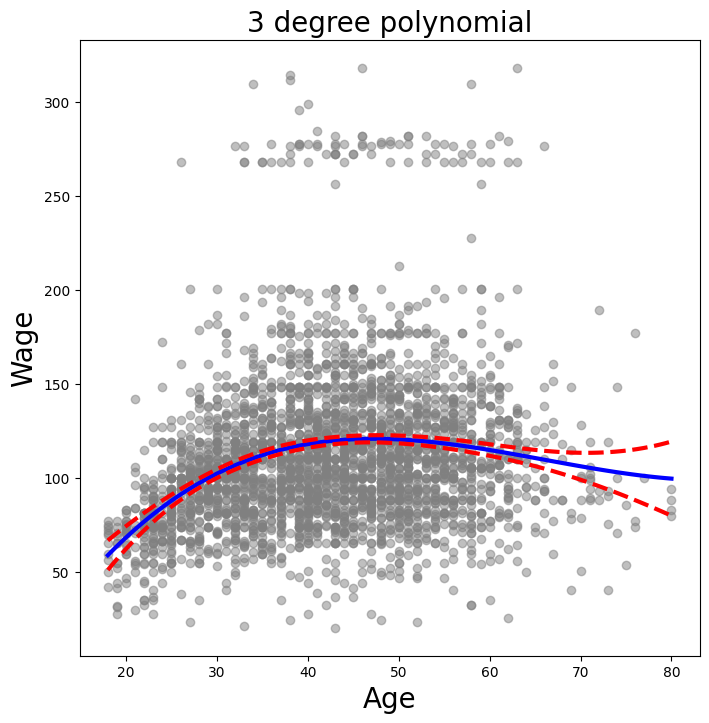

In [21]:
basis = MS([poly('age', degree = 3)]).fit(Wage)
plot_wage_fit(age_df, basis, f'{3} degree polynomial');

Оптимальным выбором будет полином 3 или 4 степени, так как при дальнейшем увелечении сложности модели MSE уменьшается незначительно. 

b) Выполните подгонку ступенчатой функции для предсказания отклика wage с использованием перменной age и примените метод перекрестной проверки для выбора оптимального количества разделителей на отрезки. Выведите график полученной модели.

In [22]:
def ols_cv(formula, X, y, k):
    """Perform k-fold cross validation to return mean MSE score
    Expects formula as Patsy formula"""
    # Разделяем датасет на k частей
    X_folds = np.array(np.array_split(X, k))
    y_folds = np.array(np.array_split(y, k))
    
    RMSEs = []
    for f in np.arange(len(X_folds)):
        #Создаем тестовый и обущающей датасет
        X_test  = X_folds[f]
        y_test  = y_folds[f]
        X_train = np.delete(X_folds, f, 0).reshape(-1, X_folds.shape[-1])
        y_train = np.delete(y_folds, f, 0).reshape(-1, 1)

        #Обучаем модель
        model = sm.OLS(y_train, X_train).fit()
        
        y_hat = model.predict(X_test)
        RMSEs += [np.sqrt(mean_squared_error(y_test, y_hat))]
    return (np.mean(RMSEs), formula)

In [25]:
f = ' + '.join(['np.power(age, {})'.format(i) for i in np.arange(1, 5+1)])

In [30]:
results = []
for steps in np.arange(2, 100):
    cuts = pd.cut(age, steps)
    X = np.asarray(pd.get_dummies(cuts))
    y = Wage['wage']
    results += [(ols_cv(f, X, y, 10)[0], steps)]

C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' instead.
  return bound(*args, **kwds)
C:\Users\10\anaconda3\envs\IntToStatisctickLearnPy312\Lib\site-packages\numpy\core\fromnumeric.py:59: FutureWarning: 'Series.swapaxes' is deprecated and will be removed in a future version. Please use 'Series.transpose' ins

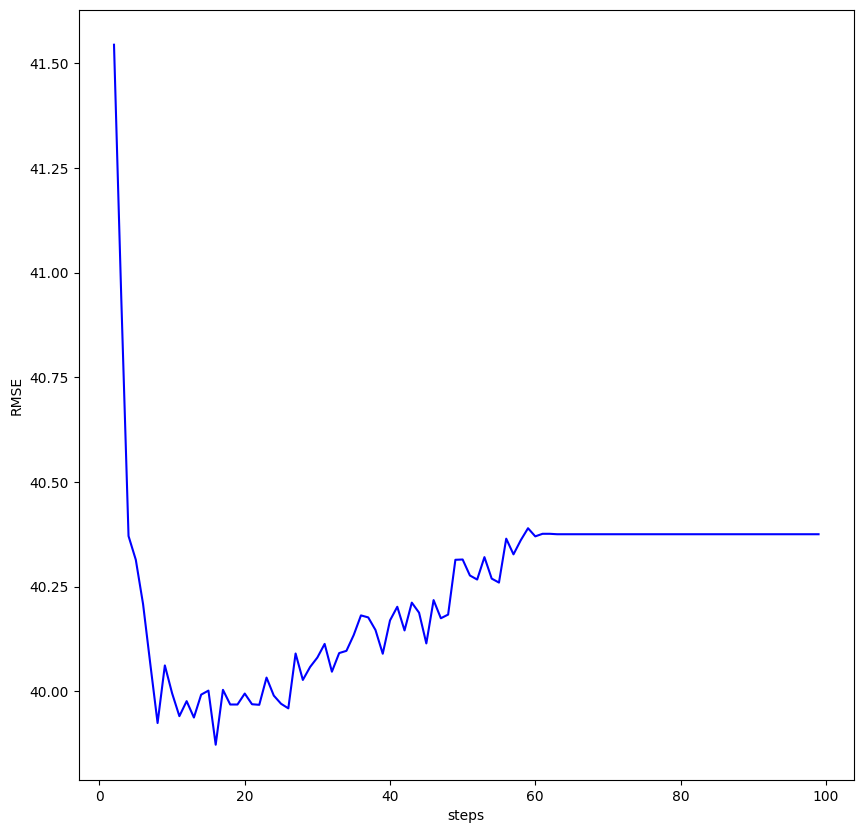

Min RMSE : 39.872054703507914
Steps   : 16


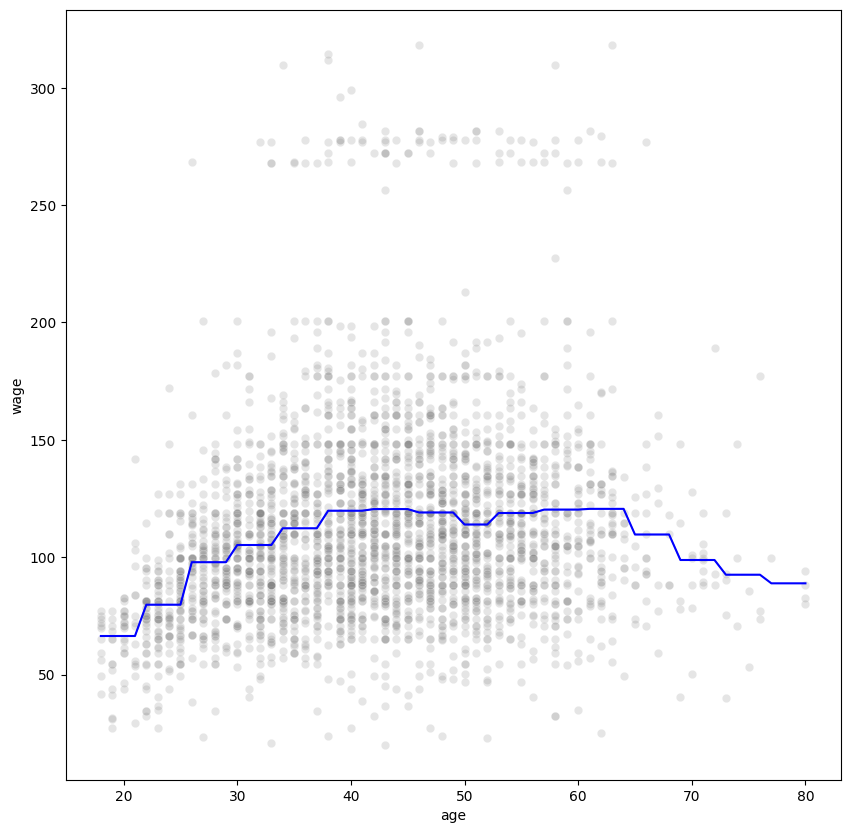

In [35]:
# CHOOSE BEST MODEL
# ----------------------------------

results = [] 
for steps in np.arange(2,100):
    # Segment data into 4 segments by age
    cuts = pd.cut(Wage['age'], steps)
    X = np.asarray(pd.get_dummies(cuts))
    y = np.asarray(Wage['wage'])
    results += [(ols_cv(f, X, y, 10)[0], steps)]


df = pd.DataFrame({'RMSE': [r[0] for r in results],
                   'steps': [r[1] for r in results]})   
fig, ax = plt.subplots(figsize=(10,10))
sns.lineplot(x='steps', y='RMSE', data=df, color='b', ax=ax)
plt.show();

# Choose model
print('Min RMSE : {}'.format(min(results)[0]))
print('Steps   : {}'.format(min(results)[1]))


# PLOT BEST MODEL
# ----------------------------------
steps = min(results)[1]

cuts = pd.cut(Wage['age'], steps)
X = np.asarray(pd.get_dummies(cuts))
y = np.asarray(Wage['wage'])

model = sm.OLS(y, X).fit(disp=0)
y_hat = model.predict(X)


fig, ax = plt.subplots(figsize=(10,10))

sns.scatterplot(x='age', y='wage',
                color='tab:gray',
                alpha=0.2,
                ax=ax,
                data=pd.concat([Wage['age'], Wage['wage']], axis=1));

sns.lineplot(x=Wage['age'], y=y_hat, ax=ax, color='blue')
plt.show();